In [47]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.pyplot import legend
from statannotations.Annotator import Annotator

import warnings
warnings.filterwarnings('ignore')

In [48]:
df = pd.read_csv('source/FReDA4.csv')
df2 = pd.read_excel('source/ANOVA_stats.xlsx')
df3 = pd.read_excel('source/ANOVA_stats2.xlsx')

In [49]:
df3.columns = ['GroupA', 'GroupB', 'meanA', 'meanB', 'diff', 'se', 'T', 'p-tukey', 'cohen', 'Trait']

x_pos_map = {
    "Satisfied couples": 0,
    "Deprived couples": 1,
    "Oversaturated couples": 2,
    "Mixed couples": 3
}
linestyle_map = {
    "Both": "--",       # Dashed line
    "Me": ":",          # Dotted line
    "Partner": "-."     # Dash-dot line
}

In [50]:
df2['Trait'] = df2['Trait'].replace({
    'Life_Satisfaction': 'Life Satisfaction',
    'Self_esteem': 'Self-esteem',
    'Communication_Quality': 'Communication Quality',
    'Relationship_Satisfaction': 'Relationship Satisfaction',
    'Conflict_Management': 'Conflict Management'
})

df2['GroupA'] = df2['GroupA'].replace({
    'Couple Mixed': 'Mixed couples',
    'Couple Satisfaction': 'Satisfied couples',
    'Couple Oversaturation': 'Oversaturated couples',
    'Couple Deprivation': 'Deprived couples',
})

df2['GroupB'] = df2['GroupB'].replace({
    'Couple Mixed': 'Mixed couples',
    'Couple Satisfaction': 'Satisfied couples',
    'Couple Oversaturation': 'Oversaturated couples',
    'Couple Deprivation': 'Deprived couples',
})

df3['Trait'] = df3['Trait'].replace({
    'Life_Satisfaction': 'Life Satisfaction',
    'Self_esteem': 'Self-esteem',
    'Communication_Quality': 'Communication Quality',
    'Relationship_Satisfaction': 'Relationship Satisfaction',
    'Conflict_Management': 'Conflict Management'
})


In [51]:
df.loc[df['Group3'] == 'Couple Satisfaction', 'Group4'] = 'Satisfied couples'
df.loc[df['Group3'] == 'Couple Deprivation', 'Group4'] = 'Deprived couples'
df.loc[df['Group3'] == 'Couple Oversaturation', 'Group4'] = 'Oversaturated couples'
df.loc[df['Group3'] == 'Couple Mixed', 'Group4'] = 'Mixed couples'

df.loc[df['Group1'] == 'SubGroup-DeprivedBoth', 'Group5'] = 'Deprived_Both'
df.loc[df['Group1'] == 'SubGroup-DeprivedMe', 'Group5'] = 'Deprived_Me'
df.loc[df['Group1'] == 'SubGroup-DeprivedPartner', 'Group5'] = 'Deprived_Partner'
df.loc[df['Group1'] == 'SubGroup-OversaturatedBoth', 'Group5'] = 'Oversaturated_Both'
df.loc[df['Group1'] == 'SubGroup-OversaturatedMe', 'Group5'] = 'Oversaturated_Me'
df.loc[df['Group1'] == 'SubGroup-OversaturatedPartner', 'Group5'] = 'Oversaturated_Partner'


In [52]:
lower_limit = {
    "Neuroticism": 3,  # 3 items, 1-5 options
    "Extraversion": 3,  # 3 items, 1-5 options
    "Openness": 3,  # 3 items, 1-5 options
    "Agreeableness": 3,  # 3 items, 1-5 options
    "Conscientiousness": 3,  # 3 items, 1-5 options
    "Depressiveness": 3,  # 3 items, 1-4 options
    "Loneliness": 1,  # 1 item, 1-5 options
    "Self-esteem": 3,  # 3 items, 1-5 options
    "Life Satisfaction": 0,  # 1 item, 0-10 options
    "Health": 1,  # 1 item, 1-5 options
    "Religiosity": 0,
    "Conservatism": 7,
    "Relationship Satisfaction": 0,  # 1 item, 0-10 options
    "Communication Quality": 6,  # 6 items, 1-5 options
    "Conflict Management": 6,  # 6 items, 1-5 options
}
upper_limit = {
    "Neuroticism": 15,
    "Extraversion": 15,
    "Openness": 15,
    "Agreeableness": 15,
    "Conscientiousness": 15,
    "Depressiveness": 12,
    "Loneliness": 5,
    "Self-esteem": 15,
    "Life Satisfaction": 10,
    "Health": 5,
    "Religiosity": 10,
    "Conservatism": 35,
    "Relationship Satisfaction": 10,
    "Communication Quality": 30,
    "Conflict Management": 30,
}
cols_to_fix = list(lower_limit.keys())
min_s = pd.Series(lower_limit)
max_s = pd.Series(upper_limit)

df_percent = df.copy()
df_percent[cols_to_fix] = ((df[cols_to_fix] - min_s) / (max_s - min_s)) * 100

In [53]:
order_couple = ["Satisfied couples", "Deprived couples", "Oversaturated couples", "Mixed couples"]
order_couple2 = ["Deprived_Both", "Deprived_Me", "Deprived_Partner",
                 "Oversaturated_Both", "Oversaturated_Me", "Oversaturated_Partner"
                 ]

Generating plot for: Neuroticism...
p-value annotation legend:
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: p <= 1.00e-03

Satisfied couples vs. Deprived couples: Custom statistical test, P_val:0.000e+00
Satisfied couples vs. Oversaturated couples: Custom statistical test, P_val:9.018e-03
Satisfied couples vs. Mixed couples: Custom statistical test, P_val:0.000e+00


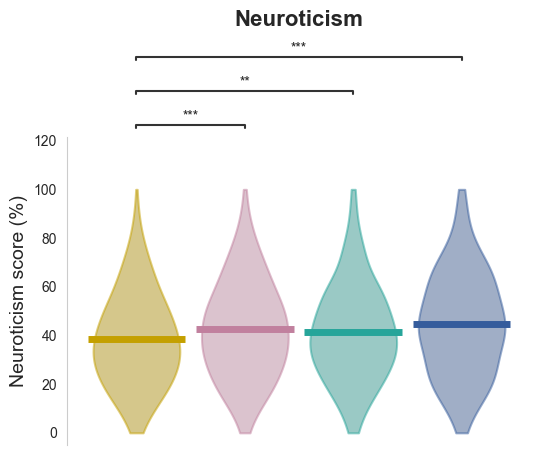

Generating plot for: Extraversion...
p-value annotation legend:
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: p <= 1.00e-03

Satisfied couples vs. Deprived couples: Custom statistical test, P_val:7.492e-03


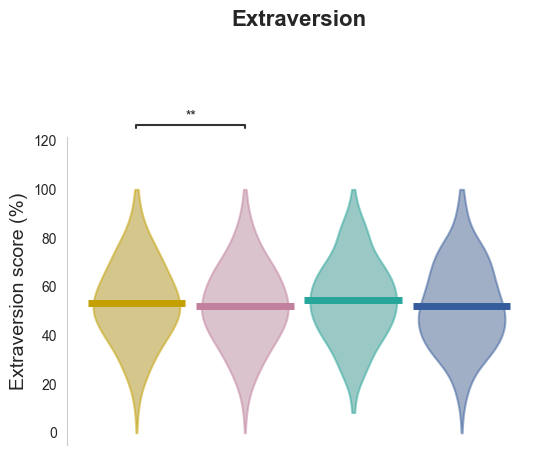

Generating plot for: Openness...
p-value annotation legend:
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: p <= 1.00e-03

Satisfied couples vs. Deprived couples: Custom statistical test, P_val:5.620e-05


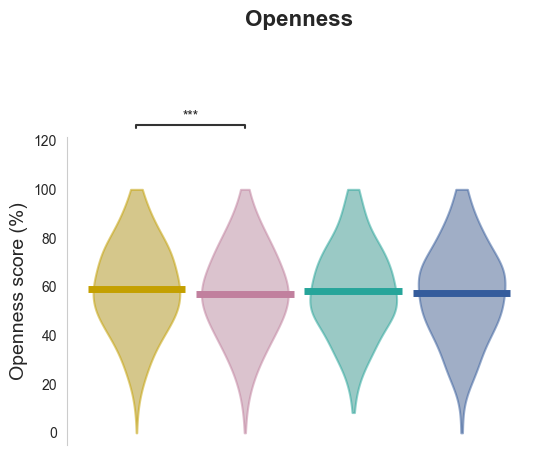

Generating plot for: Agreeableness...
p-value annotation legend:
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: p <= 1.00e-03

Satisfied couples vs. Deprived couples: Custom statistical test, P_val:3.141e-06
Satisfied couples vs. Mixed couples: Custom statistical test, P_val:4.654e-03


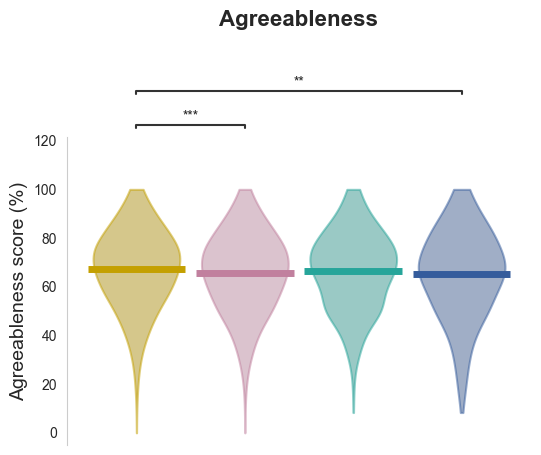

Generating plot for: Conscientiousness...


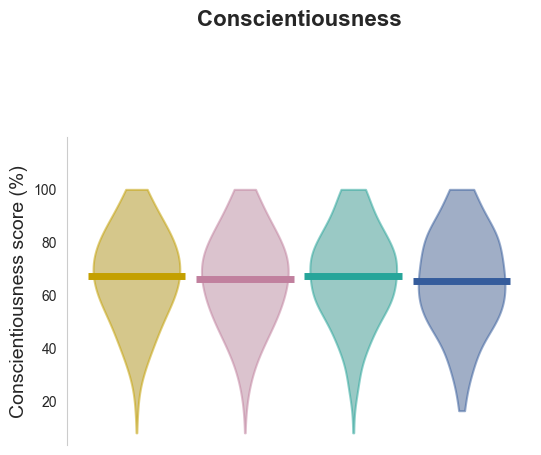

Generating plot for: Depressiveness...
p-value annotation legend:
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: p <= 1.00e-03

Satisfied couples vs. Deprived couples: Custom statistical test, P_val:0.000e+00
Satisfied couples vs. Oversaturated couples: Custom statistical test, P_val:1.838e-04
Satisfied couples vs. Mixed couples: Custom statistical test, P_val:0.000e+00


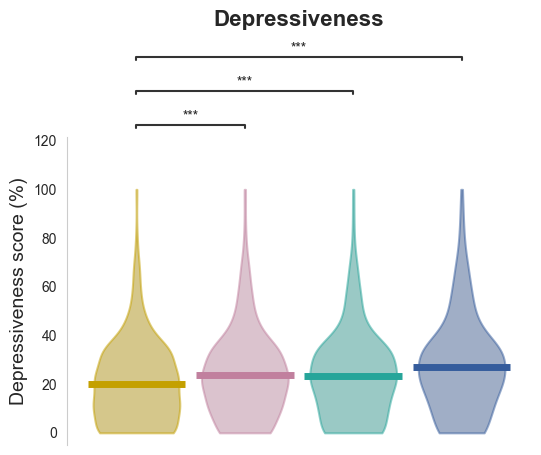

Generating plot for: Loneliness...
p-value annotation legend:
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: p <= 1.00e-03

Satisfied couples vs. Deprived couples: Custom statistical test, P_val:0.000e+00
Satisfied couples vs. Oversaturated couples: Custom statistical test, P_val:1.042e-04
Satisfied couples vs. Mixed couples: Custom statistical test, P_val:0.000e+00


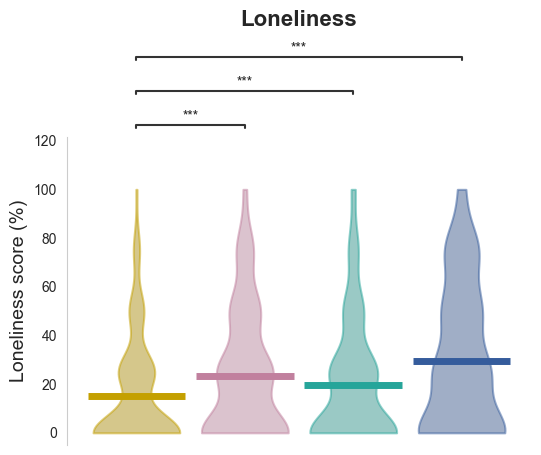

Generating plot for: Self-esteem...
p-value annotation legend:
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: p <= 1.00e-03

Satisfied couples vs. Deprived couples: Custom statistical test, P_val:0.000e+00
Satisfied couples vs. Oversaturated couples: Custom statistical test, P_val:3.663e-05
Satisfied couples vs. Mixed couples: Custom statistical test, P_val:0.000e+00


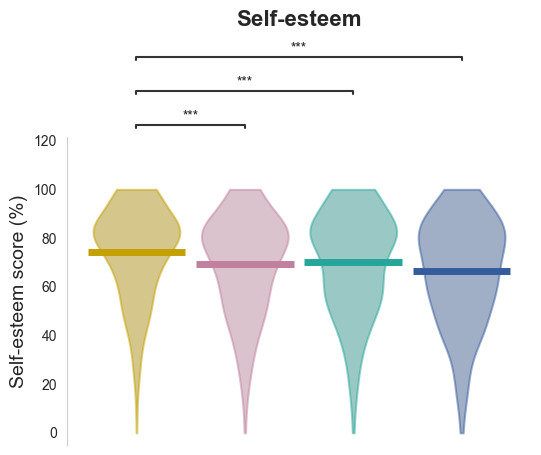

Generating plot for: Life Satisfaction...
p-value annotation legend:
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: p <= 1.00e-03

Satisfied couples vs. Deprived couples: Custom statistical test, P_val:0.000e+00
Satisfied couples vs. Oversaturated couples: Custom statistical test, P_val:6.213e-03
Satisfied couples vs. Mixed couples: Custom statistical test, P_val:0.000e+00


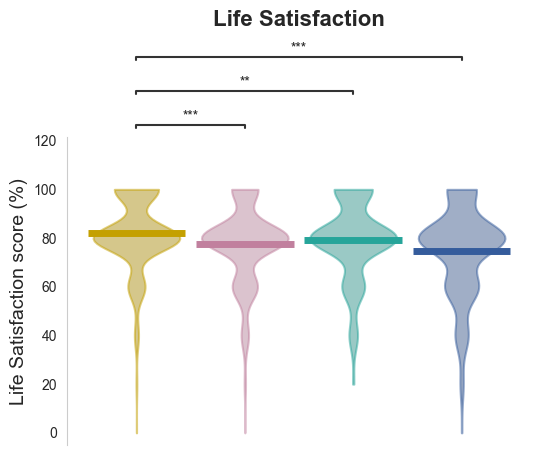

Generating plot for: Health...
p-value annotation legend:
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: p <= 1.00e-03

Satisfied couples vs. Deprived couples: Custom statistical test, P_val:0.000e+00
Satisfied couples vs. Mixed couples: Custom statistical test, P_val:0.000e+00


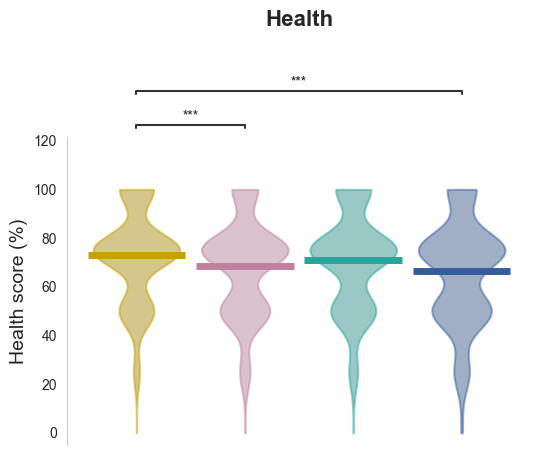

Generating plot for: Religiosity...


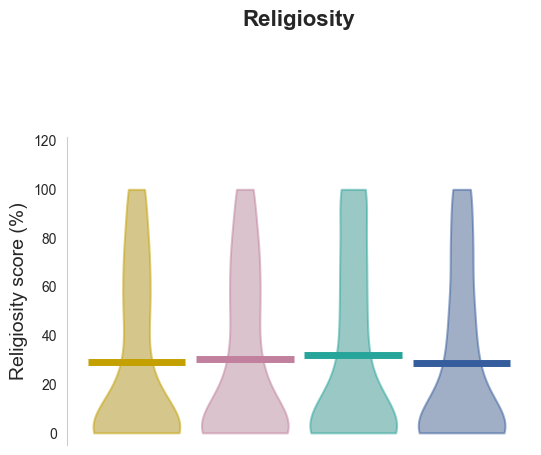

Generating plot for: Conservatism...
p-value annotation legend:
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: p <= 1.00e-03

Satisfied couples vs. Oversaturated couples: Custom statistical test, P_val:1.502e-02
Satisfied couples vs. Mixed couples: Custom statistical test, P_val:1.982e-03


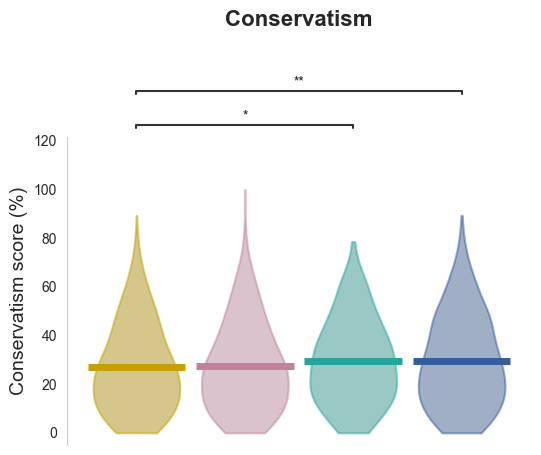

Generating plot for: Relationship Satisfaction...
p-value annotation legend:
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: p <= 1.00e-03

Satisfied couples vs. Deprived couples: Custom statistical test, P_val:0.000e+00
Satisfied couples vs. Oversaturated couples: Custom statistical test, P_val:5.008e-07
Satisfied couples vs. Mixed couples: Custom statistical test, P_val:0.000e+00


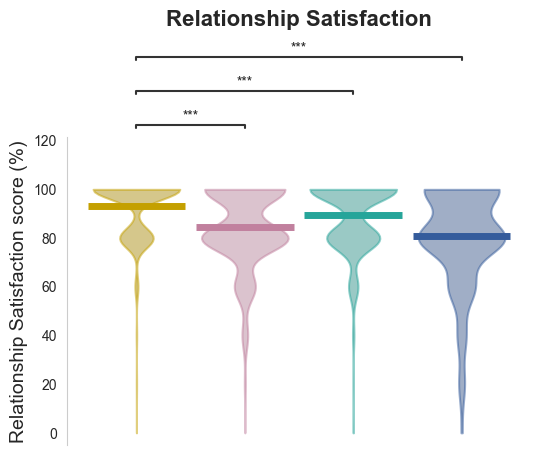

Generating plot for: Communication Quality...
p-value annotation legend:
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: p <= 1.00e-03

Satisfied couples vs. Deprived couples: Custom statistical test, P_val:0.000e+00
Satisfied couples vs. Oversaturated couples: Custom statistical test, P_val:1.644e-03
Satisfied couples vs. Mixed couples: Custom statistical test, P_val:0.000e+00


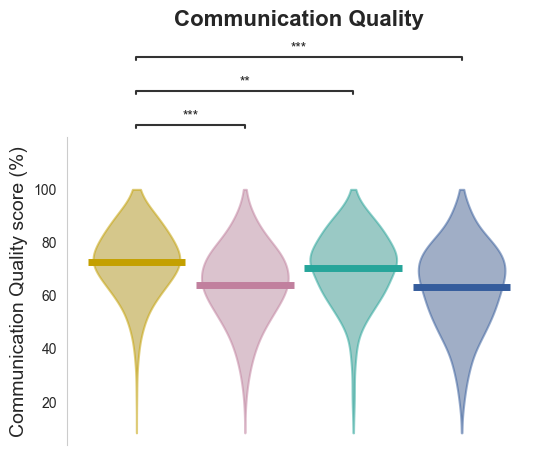

Generating plot for: Conflict Management...
p-value annotation legend:
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: p <= 1.00e-03

Satisfied couples vs. Deprived couples: Custom statistical test, P_val:0.000e+00
Satisfied couples vs. Oversaturated couples: Custom statistical test, P_val:8.437e-07
Satisfied couples vs. Mixed couples: Custom statistical test, P_val:0.000e+00


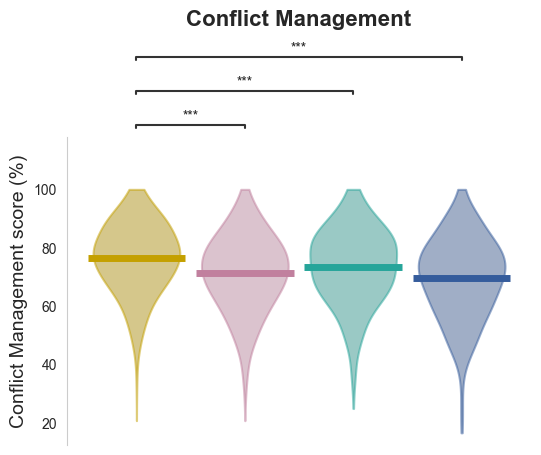

In [58]:
import os

traits = [
    "Neuroticism", "Extraversion", "Openness", "Agreeableness",
    "Conscientiousness", "Depressiveness", "Loneliness", "Self-esteem",
    "Life Satisfaction", "Health", "Religiosity", "Conservatism",
    "Relationship Satisfaction", "Communication Quality", "Conflict Management"
]

colors = ['#C4A000', '#c1809e', '#26a59a', '#355C9C']

pairs = [
    ("Satisfied couples", "Deprived couples"),
    ("Satisfied couples", "Oversaturated couples"),
    ("Satisfied couples", "Mixed couples"),
]

output_folder = "output/img/kde_ANOVA/"
os.makedirs(output_folder, exist_ok=True)

for trait in traits:
    print(f"Generating plot for: {trait}...")

    fig, ax = plt.subplots(figsize=(6, 4))

    df_long = df_percent.melt(
        id_vars=['Group4'],
        value_vars=[trait],
        var_name='Category',
        value_name='Measurement'
    )

    df_long2 = df_percent.melt(
        id_vars=['Group5'],
        value_vars=[trait],
        var_name='Category',
        value_name='Measurement'
    )

    means1 = df_long.groupby('Group4', observed=True)['Measurement'].mean()

    sns.violinplot(
        ax=ax,
        data=df_long,
        x="Group4",
        y="Measurement",
        order=order_couple,
        inner=None,
        cut=0,
        linewidth=1.5,
        palette=colors,
        alpha=0.5,
        bw_method=0.35,
    )

    min_max = 0.45
    for i, cat in enumerate(order_couple):
        if cat in means1:
            ax.hlines(
                y=means1[cat],
                xmin=i - min_max,
                xmax=i + min_max,
                colors=colors[i],
                linestyle='-',
                zorder=3,
                lw=5,
            )

    # means2 = df_long2.groupby('Group5', observed=True)['Measurement'].mean()
    #
    # for i, cat in enumerate(order_couple2):
    #     if cat in means2:
    #         ax.hlines(
    #             y=means2[cat],
    #             xmin=i - min_max,
    #             xmax=i + min_max,
    #             # colors=colors[i],
    #             linestyle='---',
    #             zorder=3,
    #             lw=5,
    #         )

    for i, violin in enumerate(ax.collections[:4]):
        violin.set_edgecolor(colors[i])

    # Plot formatting
    sns.despine(top=True, right=True, left=False, bottom=True)
    plt.xlabel("")
    plt.ylabel(f"{trait.replace('_', ' ')} score (%)", fontsize=14)
    plt.xticks([])
    plt.grid(False)
    plt.title(trait.replace('_', ' '),
              fontweight='bold',
              fontsize=16,
              pad=80
              )

    trait_stats = df2[df2['Trait'] == trait]

    significant_pairs = []
    significant_p_values = []

    for pair in pairs:
        g1_name = pair[0].replace("_", " ")
        g2_name = pair[1].replace("_", " ")

        row = trait_stats[
            ((trait_stats['GroupA'] == g1_name) & (trait_stats['GroupB'] == g2_name)) |
            ((trait_stats['GroupA'] == g2_name) & (trait_stats['GroupB'] == g1_name))
            ]

        if not row.empty:
            p_val = row['p-tukey'].values[0]
        else:
            p_val = 1.0

        if p_val <= 0.05:
            significant_pairs.append(pair)
            significant_p_values.append(p_val)

    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax + (ymax - ymin) * 0.15)

    trait_df3 = df3[df3['Trait'] == trait]

    t_min = lower_limit[trait]
    t_max = upper_limit[trait]

    plotted_sub_types = set()

    for _, row in trait_df3.iterrows():
        sub_group = row['GroupB']
        raw_mean = row['meanB']

        main_group = None
        if "Deprived" in sub_group:
            main_group = "Deprived couples"
        elif "Oversaturated" in sub_group:
            main_group = "Oversaturated couples"
        elif "Mixed" in sub_group:
            main_group = "Mixed couples"

        if not main_group:
            continue

        sub_type = sub_group.split('_')[-1]

        scaled_mean = ((raw_mean - t_min) / (t_max - t_min)) * 100

        x_pos = x_pos_map[main_group]

        label = sub_type if sub_type not in plotted_sub_types else ""
        plotted_sub_types.add(sub_type)

        sub_width = 0.35

        # ax.plot(
        #     [x_pos - sub_width, x_pos + sub_width],
        #     [scaled_mean, scaled_mean],
        #     color=colors[x_pos],
        #     linestyle=linestyle_map.get(sub_type, '-'),
        #     linewidth=1.5,
        #     zorder=4,
        #     label=label
        # )

    # if plotted_sub_types:
    #     ax.legend(title="Sub-groups", loc='upper left', bbox_to_anchor=(1.05, 1), frameon=False)

    if significant_pairs:
        annotator = Annotator(
            ax,
            significant_pairs,
            data=df_long,
            x="Group4",
            y="Measurement",
            order=order_couple,
        )

        annotator.configure(
            test=None,
            text_format="star",
            loc="outside",
            line_height=0.01,
            line_offset=0.01,
            text_offset=1,
            pvalue_thresholds=[
                (0.001, "***"),
                (0.01, "**"),
                (0.05, "*")
                # We completely removed the (1, "ns") threshold
            ]
        )

        annotator.set_pvalues(significant_p_values)
        annotator.annotate()

    # plt.tight_layout()
    safe_filename = trait.replace(" ", "_")

    # 3. Add the folder path to the filename using os.path.join (this is the safest way)
    filename = os.path.join(output_folder, f"{safe_filename}.png")

    # Save the plot
    # plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()